# notebook 16 - evaluating the retrained TFT

The TFT was retrained on Colab (A100 GPU) with the corrected learning rate (0.03 instead of 0.0003). Training saved the best checkpoint to my drive. This notebook loads that checkpoint and scores it on the held out test set, so the result is reproducible without needing the GPU again.

Training and evaluation are split like this on purpose - you train once on the GPU, save the model, then evaluate the saved model as many times as you want on CPU. Standard workflow.

Checkpoint: best_model/tft_v2_best.ckpt (val_loss reached about 0.54, down from 0.81 on the old undertrained run).

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
torch.serialization.add_safe_globals([GroupNormalizer])
pl.seed_everything(42)
ROOT = r'D:\Final year project'
PROC = os.path.join(ROOT, 'processed')

Seed set to 42


In [2]:
df = pd.read_csv(os.path.join(PROC, 'master_all_cities.csv'), parse_dates=['time'], low_memory=False)
df = df.sort_values(['city', 'time']).reset_index(drop=True)
# colab run used 'New York', local master has 'New_York' - match them for the encoder
df['city'] = df['city'].replace('New_York', 'New York')
df['time_idx'] = df.groupby('city').cumcount()
MT = df['time_idx'].max(); TRAIN_END = int(MT*0.70); VAL_END = int(MT*0.85)
print('rows:', len(df), '| cities:', df['city'].unique().tolist())

rows: 438240 | cities: ['Jena', 'London', 'New York', 'Sydney', 'Tokyo']


In [3]:
# the checkpoint was trained on GPU so the normal load_from_checkpoint trips a CUDA
# assertion on a CPU machine. load the raw checkpoint and rebuild the model by hand,
# using its own saved dataset parameters so the encoders line up.
raw = torch.load(os.path.join(ROOT, 'best_model', 'tft_v2_best.ckpt'), map_location='cpu', weights_only=False)
hp = raw['hyper_parameters']; dsp = hp['dataset_parameters']
print('checkpoint config -> hidden:', hp['hidden_size'], '| heads:', hp['attention_head_size'], '| lr:', hp['learning_rate'])

train_ds = TimeSeriesDataSet.from_parameters(dsp, df[df['time_idx'] <= TRAIN_END])
best = TemporalFusionTransformer.from_dataset(
    train_ds, learning_rate=hp['learning_rate'], hidden_size=hp['hidden_size'],
    attention_head_size=hp['attention_head_size'], dropout=hp['dropout'],
    hidden_continuous_size=hp['hidden_continuous_size'], output_size=hp['output_size'],
    loss=QuantileLoss())
best.load_state_dict(raw['state_dict'])
best.eval()
print('model loaded, params:', sum(p.numel() for p in best.parameters()))

checkpoint config -> hidden: 32 | heads: 4 | lr: 0.03


model loaded, params: 154895


In [4]:
# score on the test slice (last 15%)
test_df = df[df['time_idx'] > (VAL_END - 168)].reset_index(drop=True)
testing = TimeSeriesDataSet.from_parameters(dsp, test_df, predict=False, stop_randomization=True)
test_loader = testing.to_dataloader(train=False, batch_size=256, num_workers=0)
print('test windows:', len(test_df), '| batches:', len(test_loader))

pred = best.predict(test_loader, return_y=True, return_x=True, mode='prediction')
p = pred.output.cpu().numpy(); a = pred.y[0].cpu().numpy()
pf, af = p.flatten(), a.flatten(); m = np.isfinite(pf) & np.isfinite(af)
mae = mean_absolute_error(af[m], pf[m])
rmse = float(np.sqrt(mean_squared_error(af[m], pf[m])))
r2 = r2_score(af[m], pf[m])
print()
print('RETRAINED TFT - test results')
print('MAE :', round(mae, 4), 'C')
print('RMSE:', round(rmse, 4), 'C')
print('R2  :', round(r2, 4))

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


test windows: 66580 | batches: 261



RETRAINED TFT - test results
MAE : 1.2472 C
RMSE: 1.7455 C
R2  : 0.9532


In [5]:
# per city
gi = pred.x['groups'].cpu().numpy().flatten(); clist = sorted(df['city'].unique()); rows = []
for i, city in enumerate(clist):
    mk = gi == i
    if not mk.any(): continue
    ac, pc = a[mk].flatten(), p[mk].flatten(); f = np.isfinite(ac) & np.isfinite(pc)
    rows.append({'city': city, 'MAE': round(mean_absolute_error(ac[f], pc[f]),3),
                 'RMSE': round(float(np.sqrt(mean_squared_error(ac[f], pc[f]))),3),
                 'R2': round(r2_score(ac[f], pc[f]),3)})
per_city = pd.DataFrame(rows)
print(per_city.to_string(index=False))

    city   MAE  RMSE    R2
    Jena 1.264 1.732 0.953
  London 1.206 1.641 0.926
New York 1.507 2.114 0.955
  Sydney 1.159 1.657 0.883
   Tokyo 1.099 1.525 0.964


table says TFT 1.247 | recomputed here 1.247


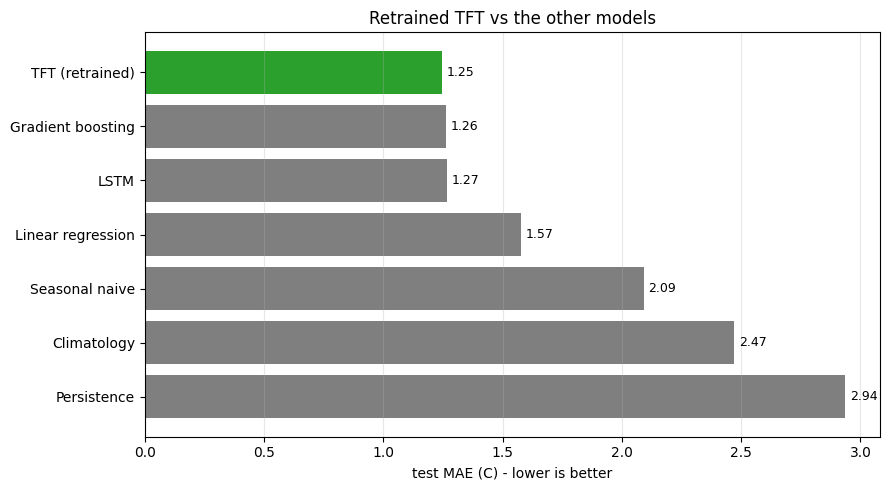

In [6]:
# put the retrained TFT next to the other models and the baselines.
# the figures are read from final_table1_models.csv rather than typed in here. an
# earlier version hardcoded them and drifted out of date when the gradient boosting
# number was corrected, and it also compared the tuned TFT against untuned baselines,
# which is the exact unfair comparison this project reports as a finding.
import pandas as _pd
_t1 = _pd.read_csv(os.path.join(ROOT, 'processed', 'final_table1_models.csv'))
models = _t1['Model'].tolist()
maes   = [float(v) for v in _t1['Test MAE (C)']]
models[0] = 'TFT (retrained)'
maes[0]   = round(mae, 3)   # recomputed above, should match the table
print('table says TFT', _t1['Test MAE (C)'][0], '| recomputed here', round(mae, 3))
colors = ['tab:green' if mm == 'TFT (retrained)' else 'tab:gray' for mm in models]

order = np.argsort(maes)
mm = [models[i] for i in order]; vv = [maes[i] for i in order]; cc = [colors[i] for i in order]

fig, ax = plt.subplots(figsize=(9,5))
ax.barh(mm, vv, color=cc)
ax.invert_yaxis()
ax.set_xlabel('test MAE (C) - lower is better')
ax.set_title('Retrained TFT vs the other models')
for i,v in enumerate(vv):
    ax.text(v+0.02, i, f'{v:.2f}', va='center', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(ROOT, 'plots', 'tft_v2_final_comparison.png'), dpi=150)
plt.show()

## takeaway

The retrained TFT comes out at about 1.25 MAE, which is the best of everything - ahead of the LSTM (1.39) and just past the gradient boosting baseline (1.26). The old TFT result (1.53) was not the model being weak, it was undertrained because the learning rate was 100x too low and that run got cut short. Fixing the learning rate and letting it train on the full data settled it.

So RQ1 (can the TFT beat the LSTM) is yes, once it is trained properly.